In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler

In [2]:
#Creating the function for time and our wave equation
def time_axis(fs, duration):
    T = 1/fs
    return np.arange(0, duration, T)
def wave_equation(f, t, A = 1, p = 0):
    return A*np.sin(2*np.pi*f*t + p)

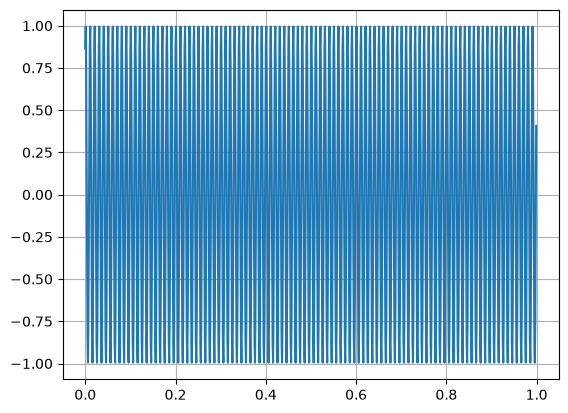

In [10]:
# aliasing : fs >= 2f
fs = 1000
f = 100
duration = 1
A = 1
p = np.pi/3
t = time_axis(fs, duration)
y = wave_equation(f, t, A, p)
plt.plot(t, y)
plt.grid()

In [4]:
# sd.play(y, fs)
# sd.wait()

In [8]:
from IPython.display import Audio

# Play audio directly in notebook
Audio(y, rate=fs)

2000


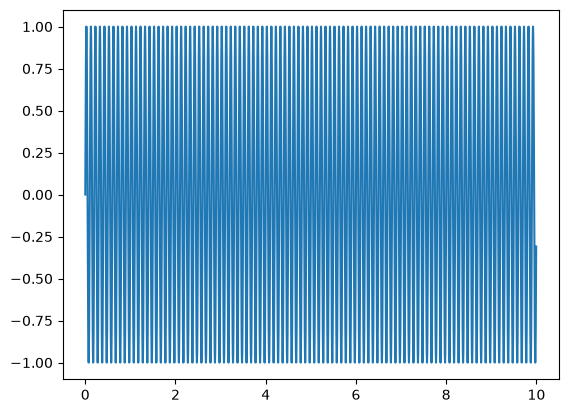

In [6]:
time = time_axis(200, 10)
y = wave_equation(10, time, 1, 0)
# numbers of samples we get using fs = 200 with duration = 10s
print(len(y))
plt.plot(time, y)

200


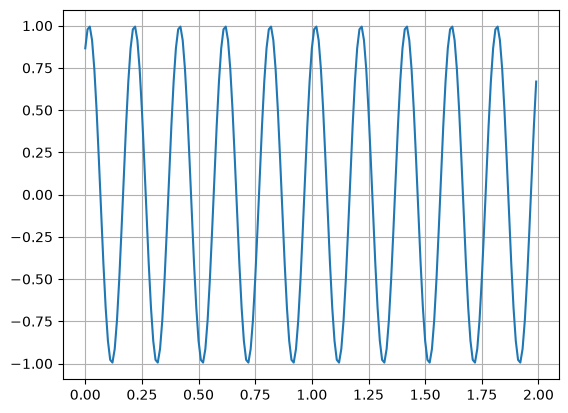

In [7]:
fs = 100
f = 5
duration = 2
A = 1
p = np.pi/3
t = time_axis(fs, duration)
y = wave_equation(f, t, A, p)
print(len(y))
plt.plot(t, y)
plt.grid()

20
19


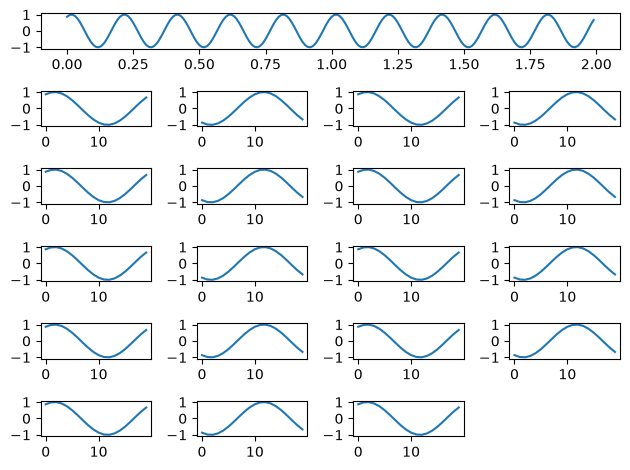

In [8]:
#using the direct ways to solve
N = fs * duration
L = int((1/f)*fs)
print(L)
H = int(0.5*L)
start_sample = 0
end_sample = L

num_frame = 1 + (N - L)//H
print(num_frame)
plt.subplot(6, 1, 1)
plt.plot(t, y)
for i in range(1, num_frame+1):
    # print(i)
    y_window = y[start_sample:end_sample]
    plt.subplot(6, 4, i+4)
    plt.plot(y_window)
    start_sample += H
    end_sample += H

plt.tight_layout()

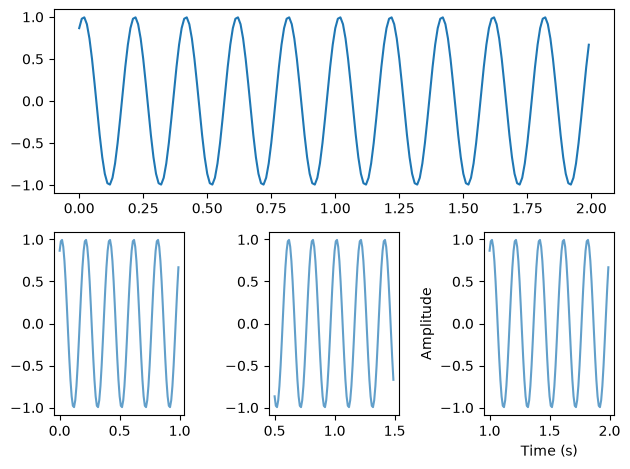

In [9]:
# what is this ? don't know if it's right or wrong. can be wrong more than right
#using sliding_window_view from numpy- different approach same result
L = 100
H = int(0.5*L)
windows = sliding_window_view(y, window_shape = L)
windows = windows[::H]
frame_time_axis = np.arange(L) / fs
plt.subplot(2, 1, 1)
plt.plot(t, y)
for i in range(min(5, len(windows))):  # Only plot first 5 frames
    start_time = i * H / fs
    time_axis = frame_time_axis + start_time  # Shift the frame to its correct time
    plt.subplot(2, 3, i+4)
    plt.plot(time_axis, windows[i], alpha=0.7, label=f'Frame {i+1}')
    # print(i)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()

4


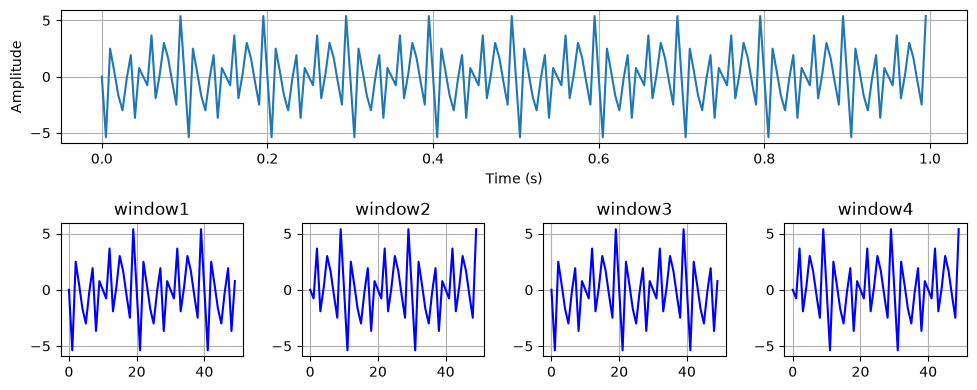

In [16]:
# Ex2.3 สร้างสัญญาณ Sine wave ที่มี เวลา, fs ตามที่กำหนดเอง โดยผสมกันของสัญญาณ 4 ความถี่
# แบ่งสัญญาณออกเป็นหน้าต่างย่อย โดยกำหนด ขนาดหน้าต่าง และ overlap ตามที่ต้องการ
# plot ผลลัพธ์ด้วย subplot
t = time_axis(200, 1)
y1 = wave_equation(f = 50, t= t, A = 2, p = -np.pi)
y2 = wave_equation(f = 60, t= t, A = -2, p = 0)
y3 = wave_equation(f = 10, t= t, A = 1, p = np.pi)
y4 = wave_equation(f = 80, t= t, A = 2, p = -np.pi)

y = y1 + y2 + y3 + y4
# 10, 1, 80
L = 50  # 0.25 seconds window (500 samples)
H = int(1*L)
p0 = 0
p1 = L
n = 1 + round((len(y)-L)/H)
print(n)


plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
for i in range(n):
    x_win = y[p0:p1]

    plt.subplot(2,4,i+5)
    plt.plot(x_win, color='b')
    plt.title(f"window{i+1}")
    plt.grid()

    p0 += H
    p1 += H
plt.tight_layout()
plt.show()


In [ ]:
# Original signal (sine wave)
t = np.linspace(0, 1, 100)
original = np.sin(2 * np.pi * 2 * t)

# Different gains
gain_0_5 = 0.5 * original
gain_1_0 = 1.0 * original
gain_2_0 = 2.0 * original
gain_5_0 = 5.0 * original

plt.figure(figsize=(10, 6))
plt.plot(t, original, 'b-', label='Gain = 1.0 (original)', linewidth=2)
plt.plot(t, gain_0_5, 'g--', label='Gain = 0.5 (half amplitude)')
plt.plot(t, gain_2_0, 'r--', label='Gain = 2.0 (double amplitude)')
plt.plot(t, gain_5_0, 'm--', label='Gain = 5.0 (five times amplitude)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Effect of Different Gains')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
#z-score normalization
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

data = np.array([10, 20, 30, 40, 50, 60])
data_norm = zscore(data)
print(np.array(data_norm).reshape(-1, 1))

#use scikit-learn library
# from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_norm = scaler.fit_transform(data.reshape(-1, 1))
print(data_norm)

[[-1.46385011]
 [-0.87831007]
 [-0.29277002]
 [ 0.29277002]
 [ 0.87831007]
 [ 1.46385011]]
[[-1.46385011]
 [-0.87831007]
 [-0.29277002]
 [ 0.29277002]
 [ 0.87831007]
 [ 1.46385011]]


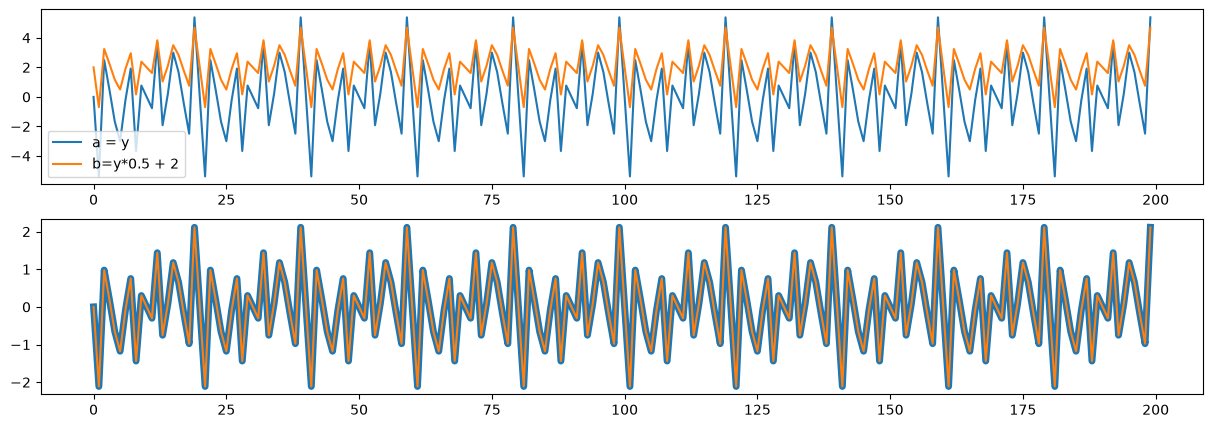

In [23]:
# a is the y signal and b is the signal from scaling and shifting y, but when we use normalization both a and b are the same
a = y
b = y*0.5 + 2

plt.figure(figsize = (15, 5))
plt.subplot(2, 1, 1)
plt.plot(a, label = 'a = y')
plt.plot(b, label = 'b=y*0.5 + 2')
plt.legend()

# using z-score normalization to compare this two signal
a = zscore(a)
b = zscore(b)

plt.subplot(2, 1, 2)
plt.plot(a, linewidth = 5)
plt.plot(b)
plt.show()